# S&P 500 Stock Data Analysis (2013-2018)

Analysis of historical stock quotations for S&P 500 companies, including:
- Data quality checks
- Daily returns calculation
- Rolling windows correlation
- Eigenvalue spectrum analysis

## 1. Import Libraries and Load Data

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
def plot_quotations_per_day(quotes_per_day, max_quotes, file_name, is_filtered=False, 
                            min_quotes=None, n_days=None):
    """
    Plot three subplots showing quotations per day statistics.
    
    Parameters:
    -----------
    quotes_per_day : pd.Series
        Series with number of quotations per day
    max_quotes : int
        Maximum possible quotations (total number of tickers)
    file_name : str
        Name of the dataset file for title
    is_filtered : bool
        Whether data is filtered (affects title)
    min_quotes : int
        Minimum quotations threshold (optional, for filtered plot titles)
    n_days : int
        Total number of days in original dataset (for histogram limits)
    """
    # Create three subplots stacked vertically
    fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 12))
    
    quotations_values = quotes_per_day.values
    bin_width = max_quotes / 50
    bins_sequence = [i * bin_width for i in range(51)]
    
    # Determine title suffix
    title_suffix = f" - FILTERED (> {min_quotes} quotations)" if is_filtered else ""
    xlabel_suffix = "Days" if is_filtered else "Timeline"
    
    # Plot 1: Time series of quotations per day
    ax0.plot(range(len(quotes_per_day)), quotations_values, linewidth=1.5, color='steelblue')
    ax0.axhline(y=max_quotes, color='red', linestyle='--', linewidth=2, label=f'Max Quotations ({max_quotes})')
    ax0.set_xlim(0, len(quotes_per_day) - 1)
    ax0.set_ylim(0, max_quotes * 1.1)
    ax0.legend(loc='upper right', fontsize=10, shadow=True)
    ax0.set_xlabel(xlabel_suffix, fontsize=12, fontweight='bold')
    ax0.set_ylabel('Count (Quotations)', fontsize=12, fontweight='bold')
    ax0.set_title(f'Available Quotations per Day Over Time (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax0.grid(True, alpha=0.3)
    
    # Plot 2: Full histogram
    ax1.hist(quotations_values, bins=bins_sequence, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlim(0, max_quotes + 1)
    ax1.set_ylim(0, (n_days if n_days else len(quotes_per_day)) * 1.1)
    ax1.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Distribution of Daily Quotation Counts (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 3: Absolute frequency histogram for values 0-10
    counts = pd.Series(quotes_per_day).value_counts().sort_index()
    for i in range(11):
        if i not in counts.index:
            counts[i] = 0
    counts = counts.sort_index()[:11]
    ax2.bar(range(11), counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax2.set_xlim(-0.5, 10.5)
    ax2.set_ylim(0, counts.max() * 1.1)
    ax2.set_xlabel('Number of Available Quotations', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count (Days)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Distribution of Daily Quotation Counts (Zoom 0-10) (S&P 500 - {file_name}){title_suffix}', 
                  fontsize=13, fontweight='bold')
    ax2.set_xticks(range(11))
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [21]:
# Load the extracted data
FILE_NAME = 'data_13_17'
data_path = Path(f'../data/processed/{FILE_NAME}.csv')
df = pd.read_csv(data_path)

# Rename first column to 'timestamp' and convert to datetime
df.rename(columns={df.columns[0]: 'timestamp'}, inplace=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Timestamp range: {df['timestamp'].min().strftime('%Y-%m-%d')} to {df['timestamp'].max().strftime('%Y-%m-%d')}")
print(f"Total records: {len(df)}")

# Extract ticker names (excluding timestamp)
ticker_cols = df.columns[1:].tolist()

# Core representation: pandas DataFrame (excluding timestamp)
prices_df = df[ticker_cols].copy()

# Display basic information
print("\nDataset shape (excluding timestamp):", prices_df.shape, "# (rows=time, cols=tickers)")
print("N. of dates (rows):", prices_df.shape[0])
print("N. of tickers/stocks (columns):", prices_df.shape[1])
print("\nColumn names (tickers/stocks):")
print(ticker_cols)
print("\nFirst few rows:")
print(prices_df.head())

Timestamp range: 2013-02-28 to 2018-02-26
Total records: 1259

Dataset shape (excluding timestamp): (1259, 640) # (rows=time, cols=tickers)
N. of dates (rows): 1259
N. of tickers/stocks (columns): 640

Column names (tickers/stocks):
['BBY', 'GME', 'RF', 'LIFE', 'CSCO', 'REG', 'TSN', 'TEG', 'KMI', 'LDOS', 'GT', 'DLTR', 'IVZ', 'AMD', 'PFE', 'HSP', 'NLSN', 'R', 'GD', 'JOY', 'EQR', 'GAS', 'PVH', 'XEC', 'MMC', 'FDO', 'CPGX', 'PG', 'CAG', 'AFL', 'LVLT', 'MKC', 'DISH', 'FLIR', 'ALB', 'TMK', 'HUM', 'BLD', 'DVA', 'LM', 'RJF', 'JPM', 'MRK', 'FFIV', 'HIG', 'UAL', 'IRM', 'STT', 'PX', 'FL', 'AEC', 'EOG', 'TMO', 'RAI', 'TEL', 'MGM', 'HON', 'ORCL', 'NFLX', 'SO', 'INTU', 'UTX', 'CB', 'ACN', 'AIV', 'COG', 'HBI', 'CCE', 'CSRA', 'MPC', 'PKG', 'XL', 'CSC', 'SWY', 'AMG', 'NKE', 'LO', 'WDC', 'DISCA', 'BEAM', 'KTF', 'UDR', 'CMCSK', 'STX', 'NCLH', 'VRSK', 'MWV', 'VRSN', 'DNB', 'PLL', 'PBI', 'UBSFY', 'WMT', 'ECL', 'CFN', 'BHI', 'MLM', 'IFF', 'ROK', 'CMG', 'AVP', 'LMT', 'EL', 'CXO', 'TWC', 'HAR', 'TDG', 'SWK', 

## 2. Data Quality Checks and Cleaning

This dataset is already cleaned with:
- Survival bias removed
- Ticker changes accounted for
- Stock splits/reverse splits handled

We'll verify data quality and set a minimum threshold for quotations per stock.

In [22]:
# Check for missing values with pandas
missing_per_col = prices_df.isna().sum()
total_missing = int(missing_per_col.sum())
n_cells = prices_df.shape[0] * prices_df.shape[1]
missing_pct = (total_missing / n_cells) * 100

print("Missing values per column:")
for ticker in ticker_cols:
    print(f"{ticker}: {missing_per_col[ticker]}")

print(f"\nTotal missing values: {total_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Missing values per column:
BBY: 2
GME: 461
RF: 275
LIFE: 1259
CSCO: 2
REG: 1032
TSN: 2
TEG: 671
KMI: 2
LDOS: 1111
GT: 2
DLTR: 2
IVZ: 2
AMD: 884
PFE: 2
HSP: 625
NLSN: 108
R: 175
GD: 2
JOY: 585
EQR: 2
GAS: 417
PVH: 2
XEC: 338
MMC: 2
FDO: 667
CPGX: 1027
PG: 2
CAG: 2
AFL: 275
LVLT: 522
MKC: 2
DISH: 1032
FLIR: 2
ALB: 843
TMK: 2
HUM: 2
BLD: 1236
DVA: 2
LM: 291
RJF: 1032
JPM: 2
MRK: 2
FFIV: 2
HIG: 2
UAL: 654
IRM: 2
STT: 2
PX: 2
FL: 800
AEC: 986
EOG: 2
TMO: 2
RAI: 150
TEL: 2
MGM: 1115
HON: 275
ORCL: 2
NFLX: 2
SO: 2
INTU: 2
UTX: 2
CB: 2
ACN: 2
AIV: 2
COG: 2
HBI: 527
CCE: 440
CSRA: 696
MPC: 275
PKG: 1115
XL: 2
CSC: 565
SWY: 775
AMG: 360
NKE: 2
LO: 683
WDC: 2
DISCA: 2
BEAM: 964
KTF: 985
UDR: 779
CMCSK: 1207
STX: 2
NCLH: 1180
VRSK: 676
MWV: 669
VRSN: 2
DNB: 212
PLL: 628
PBI: 252
UBSFY: 1006
WMT: 2
ECL: 2
CFN: 744
BHI: 164
MLM: 360
IFF: 2
ROK: 2
CMG: 2
AVP: 734
LMT: 275
EL: 2
CXO: 757
TWC: 721
HAR: 243
TDG: 843
SWK: 2
USB: 2
CERN: 2
BF_B: 756
CNX: 482
ALXN: 2
FRX: 922
TSO: 145
SPG: 2
Q: 1207
WFC: 2

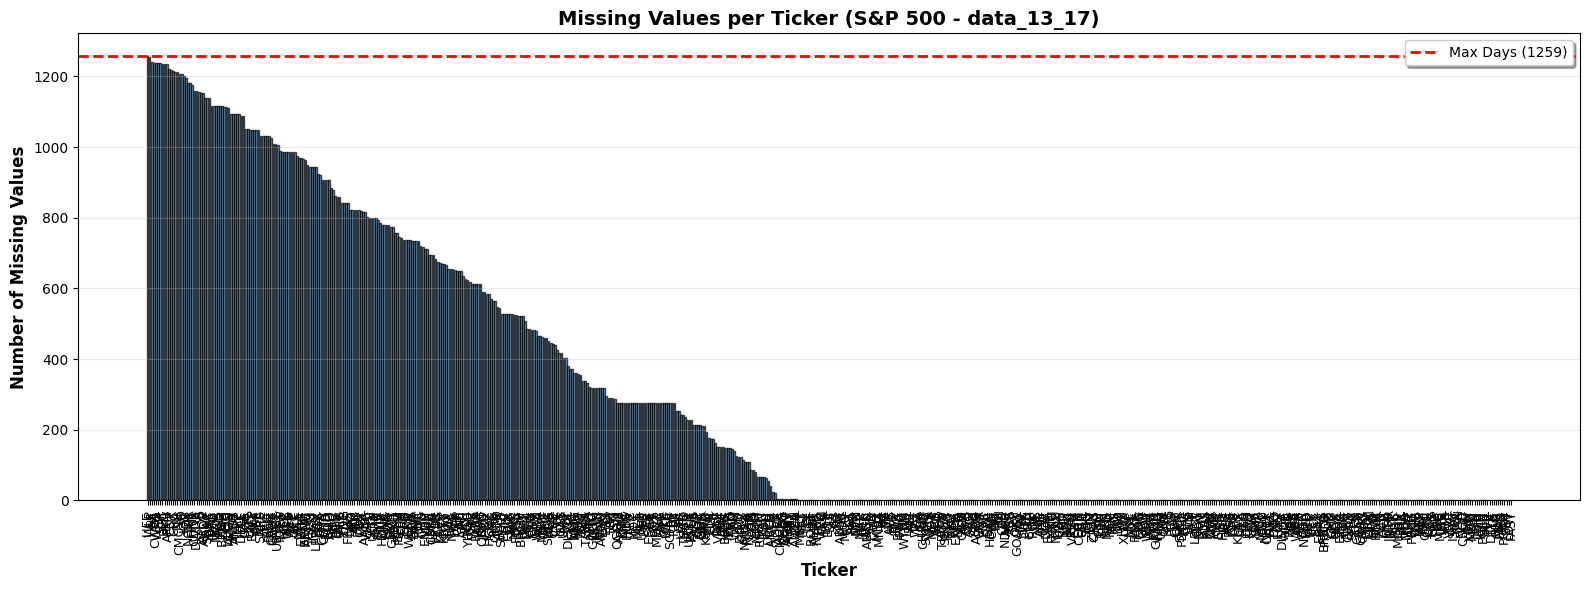

Missing values per ticker (sorted by count):
LIFE: 1259
WLP: 1256
HII: 1241
AA: 1239
CWGL: 1238
WPG: 1237
SYF: 1237
CC: 1236
BLD: 1236
BTI: 1235
APTV: 1220
COP: 1217
X: 1216
CRC: 1213
NU: 1212
CMCSK: 1207
Q: 1207
IQV: 1200
DF: 1195
NCLH: 1180
TPR: 1180
FHN: 1175
CDNS: 1158
DWDP: 1158
A: 1157
S: 1153
APOL: 1153
ANDV: 1138
SBAC: 1138
BHF: 1138
DRE: 1115
RMD: 1115
MGM: 1115
AOS: 1115
PKG: 1115
BHGE: 1115
ZMH: 1114
GCI: 1113
LDOS: 1111
ALGN: 1095
INFO: 1095
ANSS: 1095
RE: 1095
HLT: 1095
DELL: 1089
UAA: 1089
DXC: 1051
IT: 1051
UNS: 1047
BXLT: 1047
JCP: 1047
ANF: 1047
TER: 1047
SNPS: 1032
ARE: 1032
RJF: 1032
REG: 1032
DISH: 1032
CPGX: 1027
CBOE: 1009
INCY: 1009
UBSFY: 1006
IDXX: 990
TW: 986
MTZ: 986
AEC: 986
WPX: 986
ALD: 985
KTF: 985
GEC: 985
ACE: 975
MAA: 970
EVHC: 970
CLF: 965
BEAM: 964
ARNC: 949
SLM: 944
LSI: 944
INCO: 943
LPRAX: 943
IGT: 923
FRX: 922
CHTR: 907
COTY: 907
MTD: 907
COO: 907
AMD: 884
RDC: 880
FTV: 863
BTU: 859
GHC: 859
ALB: 843
LNT: 843
TDG: 843
FBHS: 843
LKQ: 821
AJG: 821


In [23]:
# Histogram of missing values per ticker, sorted by bar height
missing_sorted = missing_per_col.sort_values(ascending=False)
sorted_tickers = missing_sorted.index.tolist()
max_days = prices_df.shape[0]  # Max possible missing values

plt.figure(figsize=(16, 6))
plt.bar(
    range(len(sorted_tickers)),
    missing_sorted.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.7,
 )
plt.axhline(y=max_days, color='red', linestyle='--', linewidth=2, label=f'Max Days ({max_days})')
plt.legend(loc='upper right', fontsize=10, shadow=True)
plt.xlabel('Ticker', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Values', fontsize=12, fontweight='bold')
plt.title(f'Missing Values per Ticker (S&P 500 - {FILE_NAME})', fontsize=14, fontweight='bold')
plt.xticks(range(len(sorted_tickers)), sorted_tickers, rotation=90, fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Missing values per ticker (sorted by count):")
for ticker, n_missing in zip(sorted_tickers, missing_sorted.values):
    print(f"{ticker}: {int(n_missing)}")

Quotations per day (across all tickers):
Min: 1
Max: 504
Mean: 490.19
Std: 24.90


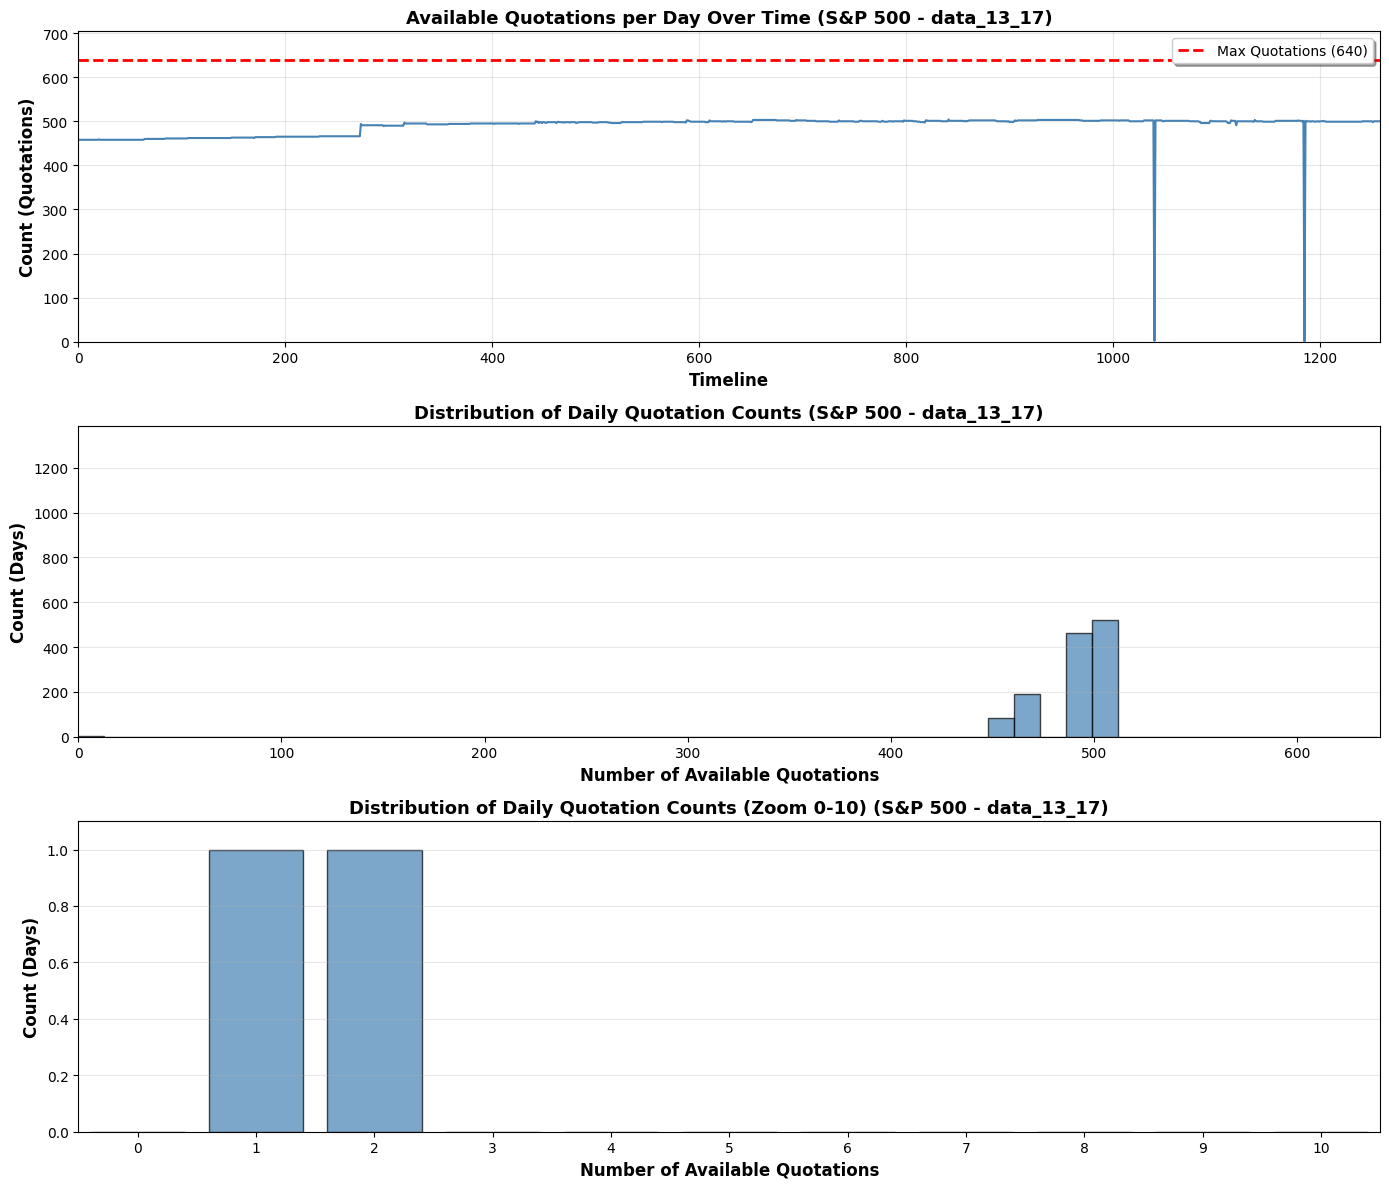

In [24]:
# Count available quotations per day (non-missing values across columns)
quotes_per_day = prices_df.notna().sum(axis=1)
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

print(f"Quotations per day (across all tickers):")
print(f"Min: {quotes_per_day.min():.0f}")
print(f"Max: {quotes_per_day.max():.0f}")
print(f"Mean: {quotes_per_day.mean():.2f}")
print(f"Std: {quotes_per_day.std():.2f}")

# Plot using the reusable function
plot_quotations_per_day(quotes_per_day, max_quotes, FILE_NAME, 
                       is_filtered=False, n_days=prices_df.shape[0])

Days removed: 2
Days retained: 1257
Filtered dataset shape: (1257, 640)

Filtered days statistics:
Min quotations: 458
Max quotations: 504
Mean quotations: 490.96
Std quotations: 15.49


C:\Users\dylan\AppData\Local\Temp\ipykernel_13944\2384116002.py:62: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, counts.max() * 1.1)


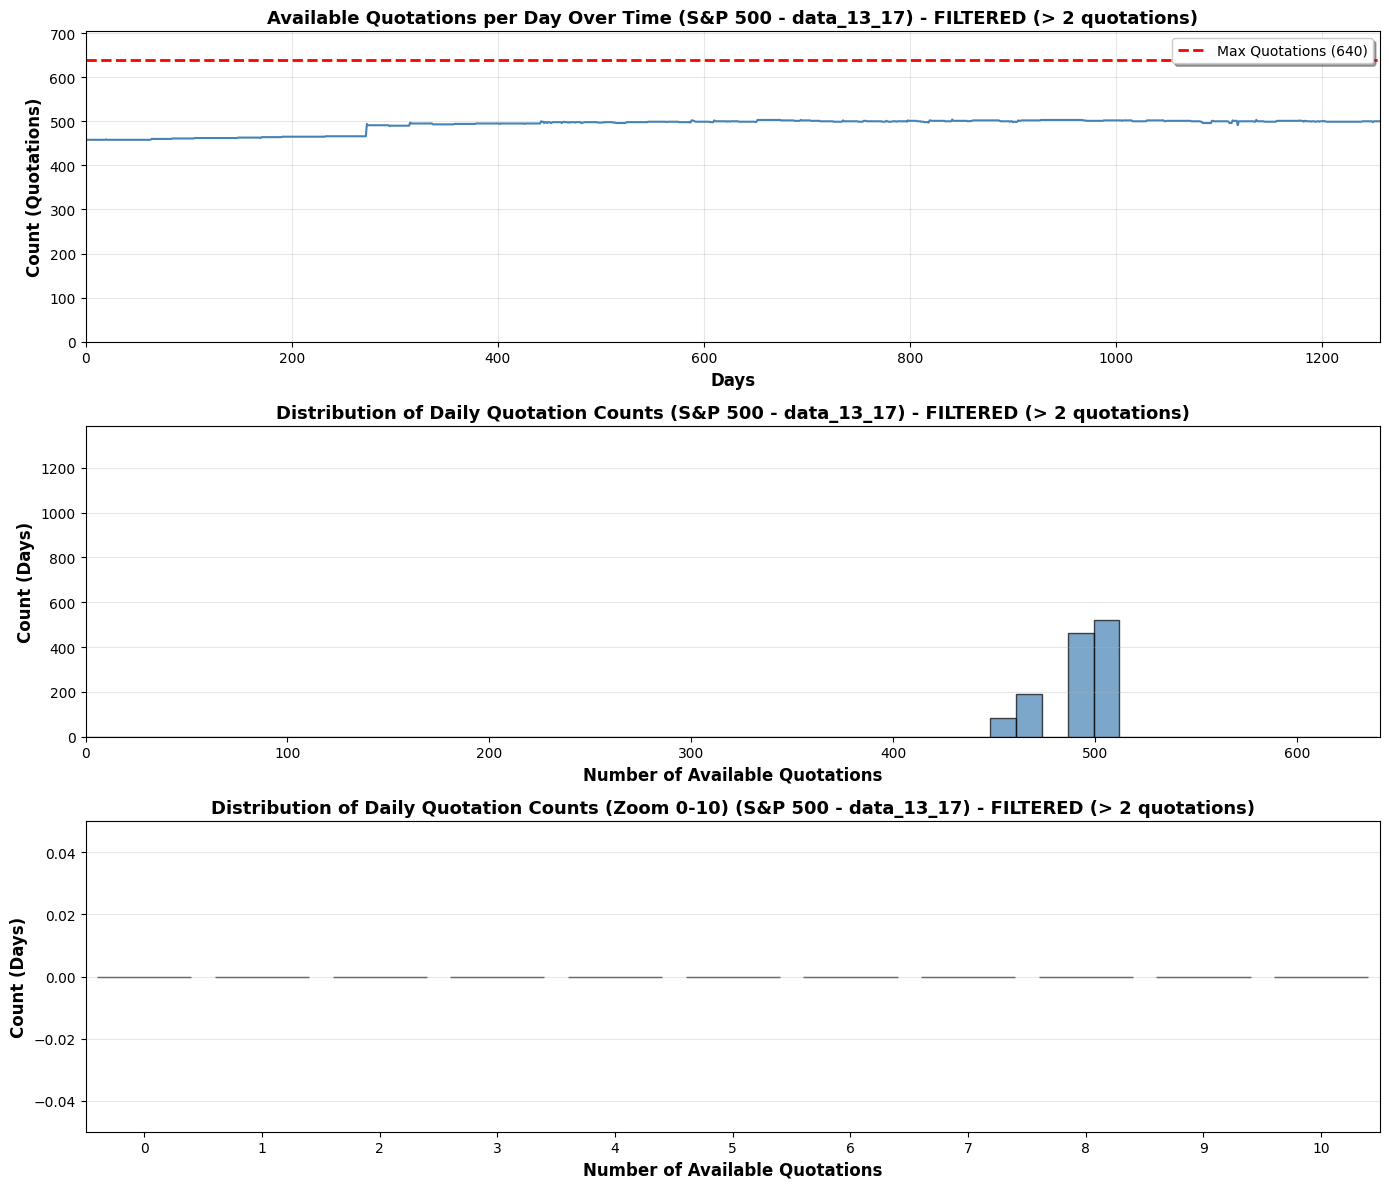

In [25]:
# Filter out days with less than or equal to MIN_QUOTES_PER_DAY quotations

MIN_QUOTES_PER_DAY = 2
valid_days_mask = quotes_per_day > MIN_QUOTES_PER_DAY
valid_day_indices = valid_days_mask[valid_days_mask].index.tolist()
max_quotes = prices_df.shape[1]  # Max possible quotations (all tickers available)

# Create filtered dataset
prices_filtered_df = prices_df.loc[valid_day_indices].copy()
quotes_per_day_filtered = quotes_per_day[valid_day_indices].copy()

print(f"Days removed: {(~valid_days_mask).sum()}")
print(f"Days retained: {valid_days_mask.sum()}")
print(f"Filtered dataset shape: {prices_filtered_df.shape}")
print(f"\nFiltered days statistics:")
print(f"Min quotations: {quotes_per_day_filtered.min():.0f}")
print(f"Max quotations: {quotes_per_day_filtered.max():.0f}")
print(f"Mean quotations: {quotes_per_day_filtered.mean():.2f}")
print(f"Std quotations: {quotes_per_day_filtered.std():.2f}")

# Plot using the reusable function with filtered data
plot_quotations_per_day(quotes_per_day_filtered, max_quotes, FILE_NAME,
                       is_filtered=True, min_quotes=MIN_QUOTES_PER_DAY, 
                       n_days=prices_df.shape[0])

In [26]:
# ===== AFTER FILTERING: Recalculate missing values per ticker =====
print("\n" + "="*70)
print("AFTER DAY FILTERING (min 10 quotations per day):")
print("="*70)

# Check for missing values in filtered dataset
missing_per_col_filtered = prices_filtered_df.isna().sum()
total_missing_filtered = int(missing_per_col_filtered.sum())
n_cells_filtered = prices_filtered_df.shape[0] * prices_filtered_df.shape[1]
missing_pct_filtered = (total_missing_filtered / n_cells_filtered) * 100

print("\nMissing values per ticker (after filtering):")
# Sort by missing values descending
missing_sorted_filtered = missing_per_col_filtered.sort_values(ascending=False)
sorted_tickers_filtered = missing_sorted_filtered.index.tolist()

for ticker in sorted_tickers_filtered:
    print(f"{ticker}: {missing_per_col_filtered[ticker]}")

print(f"\nTotal missing values (filtered): {total_missing_filtered}")
print(f"Missing percentage (filtered): {missing_pct_filtered:.2f}%")

# ===== FILTER TICKERS: Keep only those with 0 missing values =====
print("\n" + "="*70)
print("FILTERING TICKERS: Keep only those with ZERO missing values")
print("="*70)

# Identify tickers with NO missing values
no_missing_mask = missing_per_col_filtered == 0
tickers_with_complete_data = no_missing_mask[no_missing_mask].index.tolist()

# Filter the dataset to keep only complete tickers
prices_complete_df = prices_filtered_df[tickers_with_complete_data].copy()

# Validation prints
print(f"\nTickers with NO missing values: {no_missing_mask.sum()}")
print(f"Tickers removed (with missing values): {(~no_missing_mask).sum()}")
print(f"Final complete dataset shape: {prices_complete_df.shape}")
print(f"\nTickers with complete data ({len(tickers_with_complete_data)} total):")
print(tickers_with_complete_data)


AFTER DAY FILTERING (min 10 quotations per day):

Missing values per ticker (after filtering):
LIFE: 1257
WLP: 1254
HII: 1239
AA: 1237
CWGL: 1236
SYF: 1235
WPG: 1235
BLD: 1234
CC: 1234
BTI: 1233
APTV: 1218
COP: 1215
X: 1214
CRC: 1211
NU: 1210
Q: 1205
CMCSK: 1205
IQV: 1198
DF: 1193
TPR: 1178
NCLH: 1178
FHN: 1173
DWDP: 1156
CDNS: 1156
A: 1155
S: 1151
APOL: 1151
BHF: 1136
ANDV: 1136
SBAC: 1136
PKG: 1113
MGM: 1113
RMD: 1113
DRE: 1113
BHGE: 1113
AOS: 1113
ZMH: 1112
GCI: 1111
LDOS: 1109
ALGN: 1093
ANSS: 1093
INFO: 1093
RE: 1093
HLT: 1093
UAA: 1087
DELL: 1087
DXC: 1049
IT: 1049
JCP: 1045
ANF: 1045
TER: 1045
UNS: 1045
BXLT: 1045
RJF: 1030
SNPS: 1030
REG: 1030
DISH: 1030
ARE: 1030
CPGX: 1025
INCY: 1007
CBOE: 1007
UBSFY: 1004
IDXX: 988
AEC: 984
TW: 984
WPX: 984
MTZ: 984
KTF: 983
GEC: 983
ALD: 983
ACE: 973
EVHC: 968
MAA: 968
CLF: 963
BEAM: 962
ARNC: 947
SLM: 942
LSI: 942
INCO: 941
LPRAX: 941
IGT: 921
FRX: 920
CHTR: 905
COO: 905
MTD: 905
COTY: 905
AMD: 882
RDC: 878
FTV: 861
GHC: 857
BTU: 857
FBHS

## 3. Saving Filtered Data to CSV

In [27]:
# Add timestamp column at the beginning
df_complete = prices_complete_df.copy()
df_complete.insert(0, 'timestamp', df['timestamp'].iloc[valid_day_indices].reset_index(drop=True))

# Define output path
output_path = Path('../data/processed/cleaned_' + FILE_NAME + '.csv')

# Save to CSV
df_complete.to_csv(output_path, index=False)

print(f"\nFiltered dataset saved to: {output_path}")
print(f"Shape: {df_complete.shape} (rows=days, columns=tickers+timestamp)")
print(f"\nTimestamp range in filtered data:")
print(f"  From: {df_complete['timestamp'].min()}")
print(f"  To: {df_complete['timestamp'].max()}")
print(f"\nFirst few rows:")
print(df_complete.head())


Filtered dataset saved to: ..\data\processed\cleaned_data_13_17.csv
Shape: (1257, 336) (rows=days, columns=tickers+timestamp)

Timestamp range in filtered data:
  From: 2013-02-28 00:00:00
  To: 2018-02-26 00:00:00

First few rows:
   timestamp        BBY       CSCO        TSN        KMI         GT    DLTR  \
0 2013-02-28  14.313087  17.893888  21.696400  30.784206  12.417879  45.185   
1 2013-03-01  14.967250  17.872437  22.184497  30.941988  12.393971  46.110   
2 2013-03-04  15.499302  17.795216  22.213208  31.174510  12.116636  46.480   
3 2013-03-05  16.048799  18.205347  22.328055  31.108075  12.240959  46.000   
4 2013-03-06  16.354075  18.631780  22.557748  30.701162  12.336591  45.470   

         IVZ        PFE         GD  ...        XEL         IR        CCI  \
0  23.100398  23.138993  61.404848  ...  24.195093  38.409443  61.060830   
1  23.134889  23.155901  61.188030  ...  24.203524  37.884186  61.358261   
2  23.678124  23.409525  60.564676  ...  24.532307  38.000910  6